# 01. Exploratory Data Analysis

## Load Data

Load the data using wfdb

In [1]:
import wfdb
wfdb.dl_database('mitdb', dl_dir='../data/raw/')

Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 104
Generating record list for: 105
Generating record list for: 106
Generating record list for: 107
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 112
Generating record list for: 113
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 117
Generating record list for: 118
Generating record list for: 119
Generating record list for: 121
Generating record list for: 122
Generating record list for: 123
Generating record list for: 124
Generating record list for: 200
Generating record list for: 201
Generating record list for: 202
Generating record list for: 203
Generating record list for: 205
Generating record list for: 207
Generating record list for: 208
Generating record list for: 209
Generati

In [2]:
# Examine the downloaded data
record = wfdb.rdrecord('../data/raw/100')
print(record.fs)
print(record.sig_name)
print(record.p_signal.shape)

360
['MLII', 'V5']
(650000, 2)


In [3]:
# Let's examine the annotation file as well
ann = wfdb.rdann('../data/raw/100', 'atr')
print(ann.sample[:10])    # sample indices of the first 10 beats
print(ann.symbol[:10])    # beat label at each of those locations
print(len(ann.sample))    # total number of annotated beats


[  18   77  370  662  946 1231 1515 1809 2044 2402]
['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N']
2274


In [4]:
from collections import Counter
print(Counter(ann.symbol))

Counter({'N': 2239, 'A': 33, '+': 1, 'V': 1})


In [5]:
# Check a different record
ann2 = wfdb.rdann('../data/raw/106', 'atr')
print(Counter(ann2.symbol))

Counter({'N': 1507, 'V': 520, '+': 41, '~': 30})


## Signal Visualization

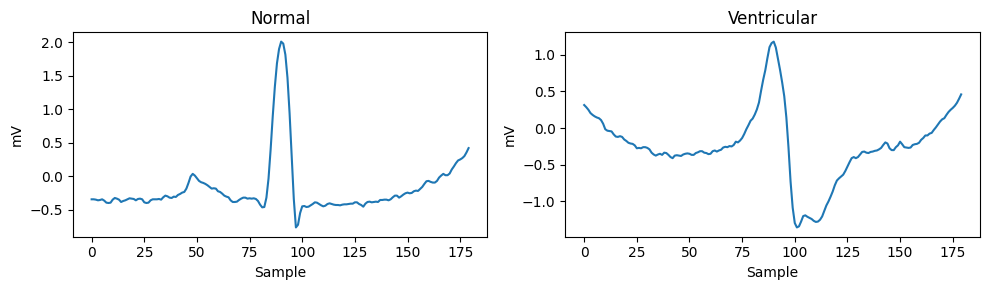

In [6]:
import matplotlib.pyplot as plt

record = wfdb.rdrecord('../data/raw/106')
ann = wfdb.rdann('../data/raw/106', 'atr')

signal = record.p_signal   # (650000, 2)
lead = signal[:, 0]        # MLII only for now

# grab sample indices and symbols, skip non-beat annotations
beats = [(s, sym) for s, sym in zip(ann.sample, ann.symbol) 
         if sym in ('N', 'V')]

# plot one N and one V, centered on the R-peak
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

for ax, (sym_to_plot, title) in zip(axes, [('N', 'Normal'), ('V', 'Ventricular')]):
    sample, sym = next((s, sy) for s, sy in beats if sy == sym_to_plot)
    window = lead[sample - 90 : sample + 90]
    ax.plot(window)
    ax.set_title(title)
    ax.set_xlabel('Sample')
    ax.set_ylabel('mV')

plt.tight_layout()
plt.show()

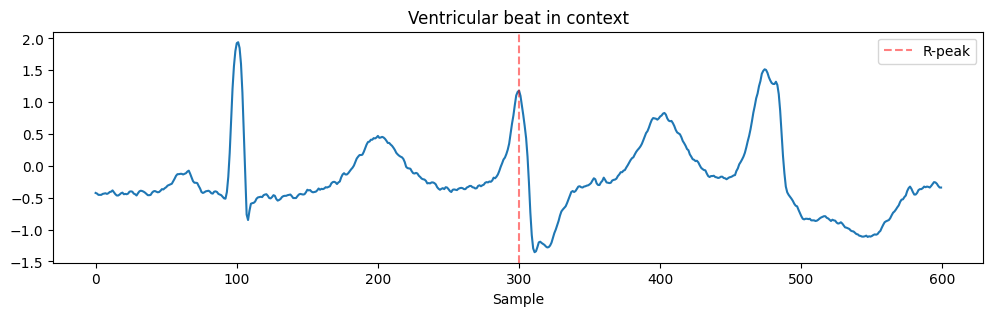

In [7]:
sample, _ = next((s, sy) for s, sy in beats if sy == 'V')

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(lead[sample - 300 : sample + 300])
ax.axvline(x=300, color='red', linestyle='--', alpha=0.5, label='R-peak')
ax.set_title('Ventricular beat in context')
ax.set_xlabel('Sample')
ax.legend()
plt.show()

N: record 106, symbol N, sample 724
S: record 100, symbol A, sample 66792
V: record 106, symbol V, sample 33045
F: record 208, symbol F, sample 697
Q: record 217, symbol /, sample 500


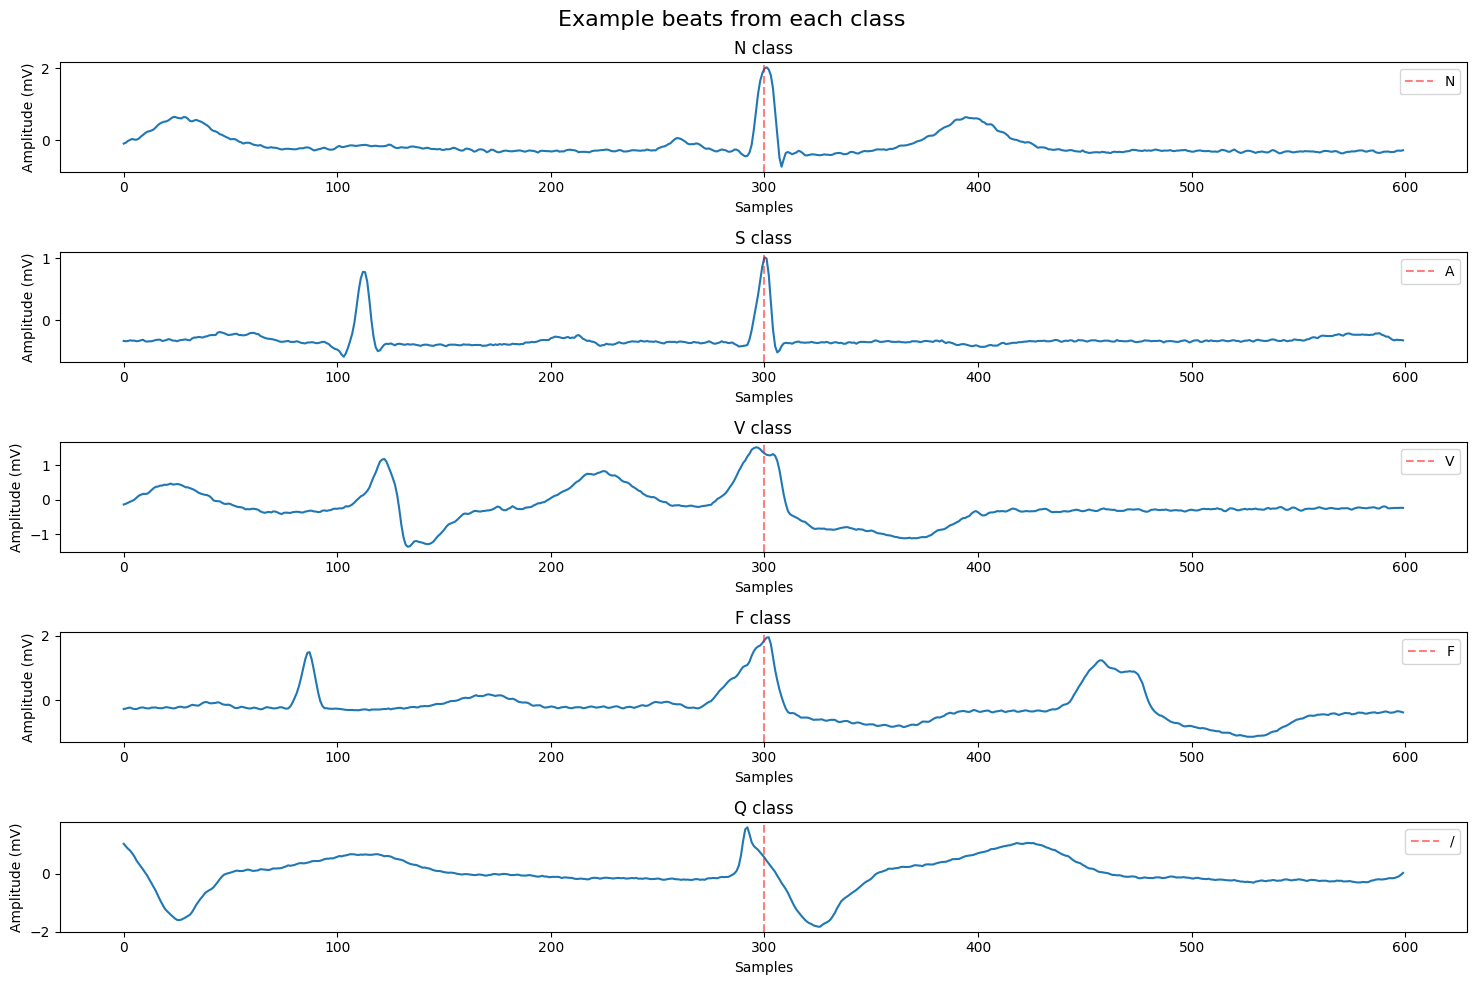

In [24]:
# Let's plot all 5 classes of beats in the same figure

examples = {
    'N':  ('106', 'N'),
    'S':  ('100', 'A'),
    'V':  ('106', 'V'),
    'F':  ('208', 'F'),
    'Q':  ('217', '/'),
}

fig, axes = plt.subplots(5, 1, figsize=(15, 10))

for ax, (label, (rec_id, sym)) in zip(axes, examples.items()):
    # your code here:
    # 1. load the record and annotation
    record = wfdb.rdrecord(f'../data/raw/{rec_id}')
    ann = wfdb.rdann(f'../data/raw/{rec_id}', 'atr')
    signal = record.p_signal
    lead = signal[:, 0]

    # 2. find the second beat with that symbol
    matches = [(s, sy) for s, sy in zip(ann.sample, ann.symbol) if sy == sym]
    sample, _ = matches[1]  # second occurrence

    print(f'{label}: record {rec_id}, symbol {sym}, sample {sample}')
    # 3. slice a window around the R-peak
    window = lead[sample - min(300, sample) : sample + 300]
    # 4. plot it
    ax.plot(window)
    # Draw a v-line at the R-peak corresponding to sample
    ax.axvline(x=min(300, sample), color='red', linestyle='--', alpha=0.5, label=sym)

    ax.set_title(label + ' class')
    ax.set_ylabel('Amplitude (mV)')
    ax.set_xlabel('Samples')
    ax.legend()


plt.suptitle('Example beats from each class', fontsize=16)
plt.tight_layout()
plt.show()

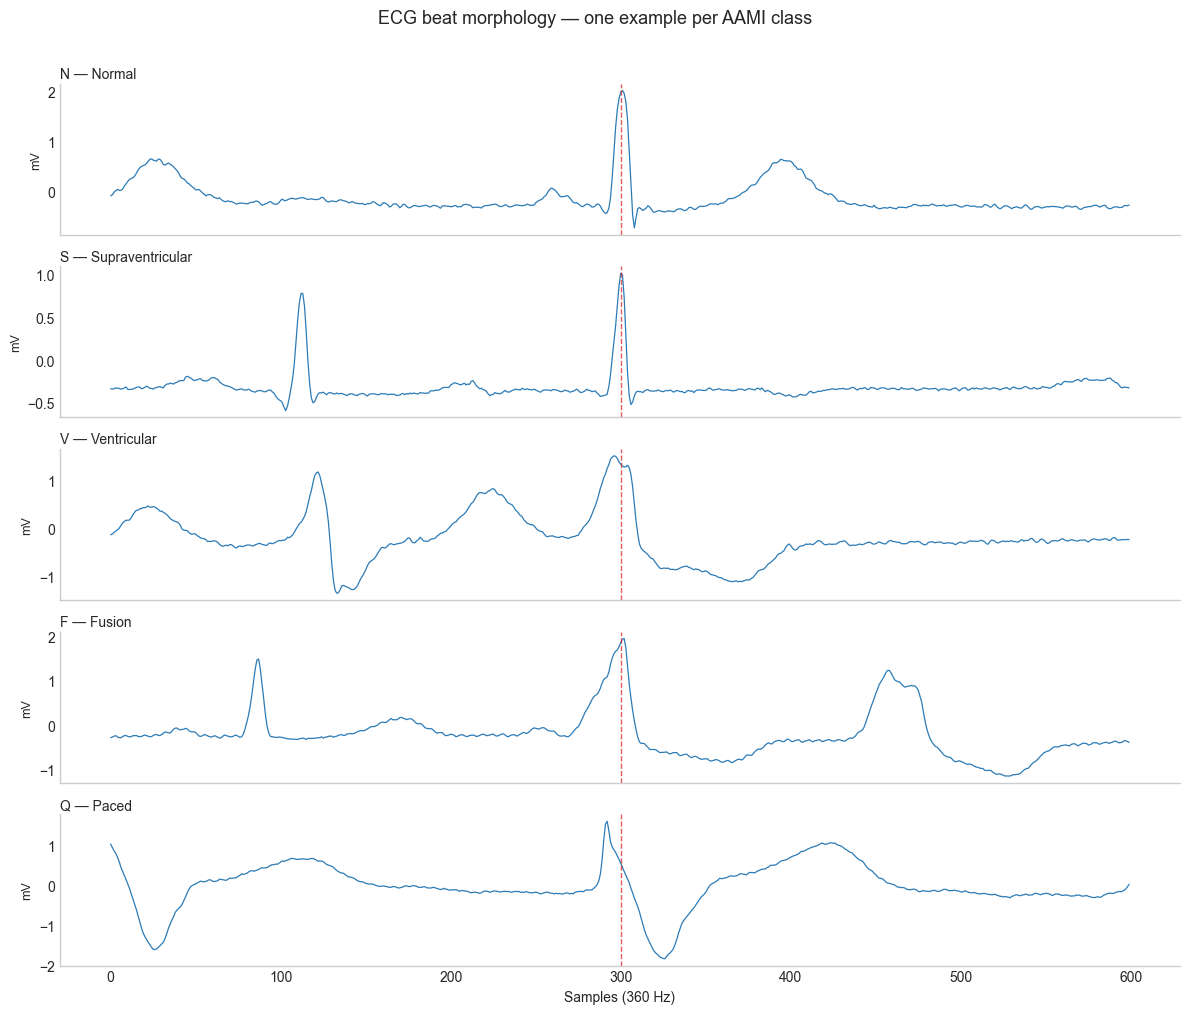

In [35]:
# Cleaner figure foor the blog post

CLASS_LABELS = {
    'N': 'N — Normal',
    'S': 'S — Supraventricular',
    'V': 'V — Ventricular',
    'F': 'F — Fusion',
    'Q': 'Q — Paced',
}

plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(5, 1, figsize=(12, 10), sharex=True)

for ax, (label, (rec_id, sym)) in zip(axes, examples.items()):
    record = wfdb.rdrecord(f'../data/raw/{rec_id}')
    ann    = wfdb.rdann(f'../data/raw/{rec_id}', 'atr')
    lead   = record.p_signal[:, 0]

    matches = [(s, sy) for s, sy in zip(ann.sample, ann.symbol) if sy == sym]
    sample, _ = matches[1]

    window = lead[sample - 300 : sample + 300]
    ax.plot(window, color='#2C7BB6', linewidth=0.9)
    ax.axvline(x=300, color='#D7191C', linestyle='--', linewidth=1, alpha=0.7)
    ax.set_ylabel('mV', fontsize=9)
    ax.set_title(CLASS_LABELS[label], fontsize=10, loc='left', pad=4)
    ax.grid(False)
    ax.spines[['top', 'right']].set_visible(False)

axes[-1].set_xlabel('Samples (360 Hz)', fontsize=10)
fig.suptitle('ECG beat morphology — one example per AAMI class',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../results/beat_examples.png', dpi=150, bbox_inches='tight')
plt.show()

## Class distribution

In [36]:
from pathlib import Path
from collections import Counter

AAMI_MAP = {
    'N': 'N', 'L': 'N', 'R': 'N', 'e': 'N', 'j': 'N',
    'A': 'S', 'a': 'S', 'J': 'S', 'S': 'S',
    'V': 'V', 'E': 'V',
    'F': 'F',
    '/': 'Q', 'f': 'Q', 'Q': 'Q',
}

counts = Counter()
data_dir = Path('../data/raw')

for hea_file in sorted(data_dir.glob('*.hea')):
    rec_id = hea_file.stem
    ann = wfdb.rdann(str(data_dir / rec_id), 'atr')
    for sym in ann.symbol:
        if sym in AAMI_MAP:
            counts[AAMI_MAP[sym]] += 1

print(counts)

Counter({'N': 90631, 'Q': 8043, 'V': 7236, 'S': 2781, 'F': 803})


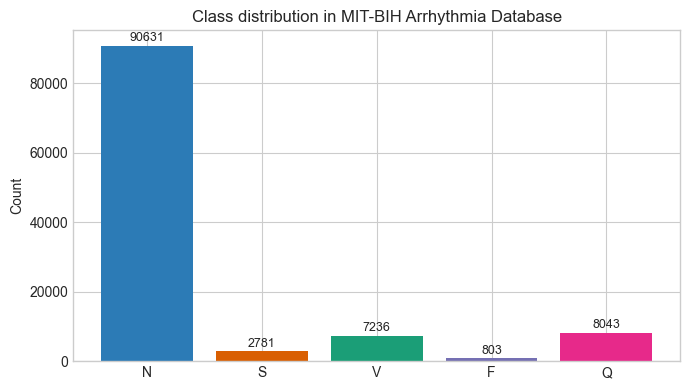

In [43]:
classes = ['N', 'S', 'V', 'F', 'Q']
values  = [counts[c] for c in classes]

fig, ax = plt.subplots(figsize=(7, 4))

# your code — bar chart, label each bar with its count,
# maybe log scale on y-axis so S, F, Q aren't invisible
bars = ax.bar(classes, values, color=['#2C7BB6', '#D95F02', '#1B9E77', '#7570B3', '#E7298A'])
# Add count labels on top of each bar
for bar, value in zip(bars, values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 500, str(value), 
            ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Count')
ax.set_title('Class distribution in MIT-BIH Arrhythmia Database')

plt.tight_layout()
plt.savefig('../results/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()